<a href="https://colab.research.google.com/github/gopika-vit/-AI-DS-/blob/main/Exploratory_Data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import mailbox
gfile="/content/drive/My Drive/All mail Including Spam and Trash.mbox"

mbox=mailbox.mbox(gfile)
mbox


In [ ]:
for key in mbox[0].keys():
  print(key)



X-GM-THRID
X-Gmail-Labels
Delivered-To
Received
X-Received
ARC-Seal
ARC-Message-Signature
ARC-Authentication-Results
Return-Path
Received
Received-SPF
Authentication-Results
DKIM-Signature
X-Google-DKIM-Signature
X-Gm-Message-State
X-Google-Smtp-Source
MIME-Version
X-Received
Date
X-Notifications
X-Notifications-Bounce-Info
Message-ID
Subject
From
To
Content-Type


In [ ]:
import csv
with open('mailbox.csv', 'w') as outputfile:
 writer = csv.writer(outputfile)
 writer.writerow(['subject','from','date','to','label','thread'])
 for message in mbox:
  writer.writerow([
  message['subject'],
  message['from'],
  message['date'],
  message['to'],
  message['X-Gmail-Labels'],
  message['X-GM-THRID']
 ]
 )


In [ ]:
dfs = pd.read_csv('mailbox.csv', names=['subject', 'from', 'date', 'to',
'label', 'thread'])

dfs.dtypes

,0
subject,object
from,object
date,object
to,object
label,object
thread,object


In [ ]:
dfs['date'] = dfs['date'].apply(lambda x: pd.to_datetime(x,errors='coerce', utc=True))
dfs = dfs[dfs['date'].notna()]
dfs




,subject,from,date,to,label,thread
1,"New assignment: ""Assignment-1""","""Harshlata Vishwakarma (Classroom)"" <no-reply@...",2025-07-31 09:35:45+00:00,gopika.25mas10037@vitbhopal.ac.in,"Inbox,Important,Category Updates,Unread",1839154641874347294
2,ID card printing and collection - regarding,Assistant Director CTS <ad.cts@vitbhopal.ac.in>,2025-07-15 15:18:01+00:00,Karthick Raja R <karthick.raja@vitbhopal.ac.in>,"Inbox,Important,Opened,Category Personal,Starred",1837726637276053728
3,2-Step Verification turned on,Google <no-reply@accounts.google.com>,2025-07-16 11:00:02+00:00,gopika.25mas10037@vitbhopal.ac.in,"Inbox,Important,Opened,Category Updates",1837800991201803812
4,"Due tomorrow: ""Assignment-1""","""Harshlata Vishwakarma (Classroom)"" <no-reply@...",2025-08-01 04:26:20+00:00,gopika.25mas10037@vitbhopal.ac.in,"Inbox,Important,Category Updates,Unread",1839225773176447661
5,=?UTF-8?Q?New_assignment=3A_=22Exp_No_3_=2D_So...,"""Velmani R (Classroom)"" <no-reply@classroom.go...",2025-08-08 10:10:51+00:00,gopika.25mas10037@vitbhopal.ac.in,"Inbox,Important,Category Updates,Unread",1839881626122762211
...,...,...,...,...,...,...
67,"Class invitation: ""Freshers PG BL20252601010...","""Velmani R (Classroom)"" <no-reply@classroom.go...",2025-07-23 06:12:39+00:00,gopika.25mas10037@vitbhopal.ac.in,"Inbox,Important,Opened,Category Updates",1838417089099840865
68,Re: FFCS Final Course Registration_Fall Semest...,Dean Academics <dean.acad@vitbhopal.ac.in>,2025-07-21 05:47:41+00:00,"pg25@vitbhopal.ac.in, mba24@vitbhopal.ac.in","Inbox,Important,Opened,Category Forums",1838005144946116394
69,FFCS Final Course Registration_Fall Semester_2...,Dean Academics <dean.acad@vitbhopal.ac.in>,2025-07-18 17:04:40+00:00,"pg25@vitbhopal.ac.in, mba24@vitbhopal.ac.in","Inbox,Important,Opened,Category Forums",1838005144946116394
70,Regarding orientation class,GOPIKA A 25MAS10037 <gopika.25mas10037@vitbhop...,2025-07-16 10:30:23+00:00,pc.mas@vitbhopal.ac.in,"Archived,Sent",1837798900267293498


In [ ]:
dfs.to_csv('gmail.csv')
import re
def extract_email_ID(string):
  email = re.findall(r'<(.+?)>', string)
  if not email:
    email = list(filter(lambda y: '@' in y, string.split()))
  return email[0] if email else np.nan




In [ ]:
dfs['from'] = dfs['from'].apply(lambda x: extract_email_ID(x))

In [ ]:
myemail = 'gopika.25mas10037@vitbhopal.ac.in'
dfs['label'] = dfs['from'].apply(lambda x: 'sent' if x==myemail
else 'inbox')

In [ ]:
import datetime
import pytz
def refactor_timezone(x):
 isttime = pytz.timezone('Asia/Calcutta')
 return x.astimezone(isttime)

In [ ]:
dfs['date'] = dfs['date'].apply(lambda x: refactor_timezone(x))

In [ ]:
dfs['dayofweek'] = dfs['date'].apply(lambda x: x.day_name())
dfs['dayofweek'] = pd.Categorical(dfs['dayofweek'], categories=[
 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
 'Saturday', 'Sunday'], ordered=True)


In [ ]:
dfs['timeofday'] = dfs['date'].apply(lambda x: x.hour + x.minute/60
+ x.second/3600)

In [ ]:
dfs['hour'] = dfs['date'].apply(lambda x: x.hour)

In [ ]:
dfs['year_int'] = dfs['date'].apply(lambda x: x.year)

In [ ]:
dfs['year'] = dfs['date'].apply(lambda x: x.year +
x.dayofyear/365.25)

In [ ]:
dfs.index = dfs['date']
del dfs['date']

In [ ]:
#1How many emails did I send during a given timeframe?
print(dfs.index.min().strftime('%a, %d %b %Y %I:%M %p'))
print(dfs.index.max().strftime('%a, %d %b %Y %I:%M %p'))
print(dfs['label'].value_counts())


Sat, 05 Jul 2025 04:03 PM
Mon, 11 Aug 2025 12:02 AM
label
inbox    61
sent     10
Name: count, dtype: int64


/tmp/ipython-input-3656017731.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipython-input-3656017731.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,


<Axes: title={'center': 'Received'}>

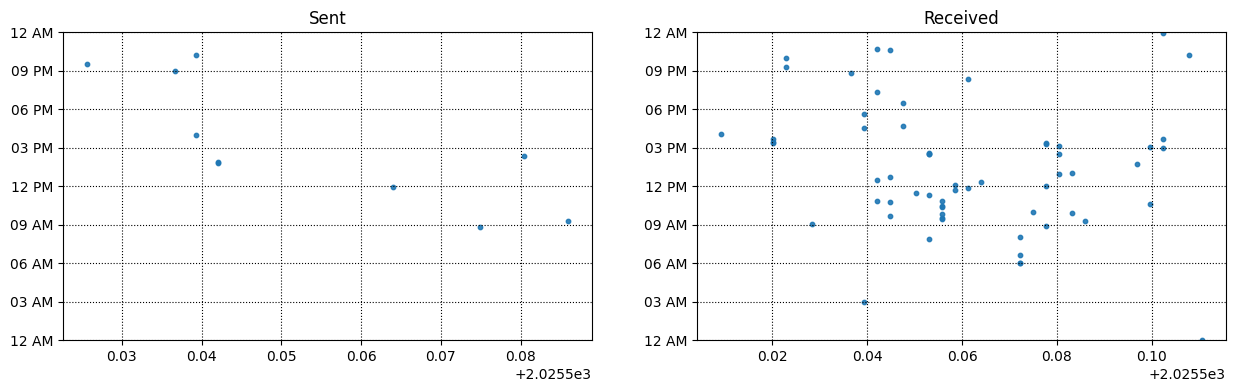

In [ ]:
#2.At what times of the day do I send and receive emails with Gmail?
sent = dfs[dfs['label']=='sent']
received = dfs[dfs['label']=='inbox']
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import ndimage
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
def plot_todo_vs_year(df, ax, color='C0', s=10, title=''):
  ind = np.zeros(len(df), dtype='bool')
  isttime = pytz.timezone('Asia/Calcutta')
  df[~ind].plot.scatter('year', 'timeofday', s=s, alpha=0.9, ax=ax,color=color)
  ax.set_ylim(0, 24)
  ax.yaxis.set_major_locator(MaxNLocator(8))
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
  24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);
  ax.set_xlabel('')
  ax.set_ylabel('')
  ax.set_title(title)
  ax.grid(ls=':', color='k')
  return ax
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_todo_vs_year(sent, ax[0], title='Sent')
plot_todo_vs_year(received, ax[1], title='Received')

In [ ]:
# 3.What is the average number of emails per day?

def plot_number_perdhour_per_year(df, ax, label=None, dt=1, smooth=False, weight_fun=None, **plot_kwargs):
  tod = df[df['timeofday'].notna()]['timeofday'].values
  year = df[df['year'].notna()]['year'].values
  Ty = year.max() - year.min()
  T = tod.max() - tod.min()
  bins = int(T / dt)
  if weight_fun is None:
    weights = 1 / (np.ones_like(tod) * Ty * 365.25 / dt)
  else:
    weights = weight_fun(df)
  if smooth:
    hst, xedges = np.histogram(tod, bins=bins,weights=weights)
    x = np.delete(xedges, -1) + 0.5*(xedges[1] - xedges[0])
    hst = ndimage.gaussian_filter(hst, sigma=0.75)
    f = interp1d(x, hst, kind='cubic')
    x = np.linspace(x.min(), x.max(), 10000)
    hst = f(x)
    ax.plot(x, hst, label=label, **plot_kwargs)
  else:
    ax.hist(tod, bins=bins, weights=weights, label=label,**plot_kwargs)
    ax.grid(ls=':', color='k')
    orientation = plot_kwargs.get('orientation')
    if orientation is None or orientation == 'vertical':
      ax.set_xlim(0, 24)
      ax.xaxis.set_major_locator(MaxNLocator(8))
      ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,24))), "%H").strftime("%I %p") for ts in ax.get_xticks()])
    elif orientation == 'horizontal':
      ax.set_ylim(0, 24)
      ax.yaxis.set_major_locator(MaxNLocator(8))
      ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,24))), "%H").strftime("%I %p") for ts in ax.get_yticks()])
class TriplePlot:
  def _init_(self):
    gs = gridspec.GridSpec(6, 6)
    self.ax1 = plt.subplot(gs[2:6, :4])
    self.ax2 = plt.subplot(gs[2:6, 4:6], sharey=self.ax1)
    plt.setp(self.ax2.get_yticklabels(), visible=False)
    self.ax3 = plt.subplot(gs[:2, :4])
    plt.setp(self.ax3.get_xticklabels(), visible=False)

  def plot(self, df, color='darkblue', alpha=0.8, markersize=0.5,yr_bin=0.1, hr_bin=0.5):
    plot_todo_vs_year(df, self.ax1, color=color, s=markersize)
    plot_number_perdhour_per_year(df, self.ax2, dt=hr_bin, color=color, alpha=alpha, orientation='horizontal')
    self.ax2.set_xlabel('Average emails per hour')
    plot_number_perday_per_year(df, self.ax3, dt=yr_bin, color=color, alpha=alpha)
    self.ax3.set_ylabel('Average emails per day')





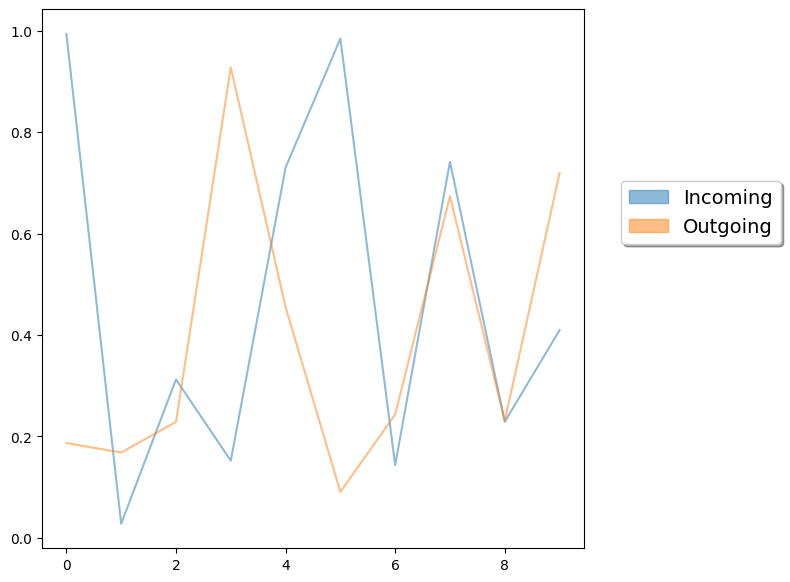

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Example TriplePlot stub (replace with your actual implementation)
class TriplePlot:
    def plot(self, data, **kwargs):
        plt.plot(data, **kwargs)

# Example data
received = np.random.rand(10)
sent = np.random.rand(10)

# Plot
plt.figure(figsize=(7, 7))
tpl = TriplePlot()
tpl.plot(received, color='C0', alpha=0.5)
tpl.plot(sent, color='C1', alpha=0.5)

# Legend patches
p1 = mpatches.Patch(color='C0', label='Incoming', alpha=0.5)
p2 = mpatches.Patch(color='C1', label='Outgoing', alpha=0.5)

plt.legend(handles=[p1, p2], bbox_to_anchor=(1.05, 0.7),
           fontsize=14, shadow=True)
plt.show()

Top 5 most frequent senders (from):
from
GOPIKA A 25MAS10037 <gopika.25mas10037@vitbhopal.ac.in>           10
"Velmani R (Classroom)" <no-reply@classroom.google.com>            6
Assistant Dean First year <ad.fy@vitbhopal.ac.in>                  6
"Programme Chair - M. Tech AI and DS" <pc.mas@vitbhopal.ac.in>     5
Chief Warden Ladies Hostel <cw.lh@vitbhopal.ac.in>                 5
Name: count, dtype: int64

Top 5 most frequent recipients (to):
to
gopika.25mas10037@vitbhopal.ac.in              28
pg25@vitbhopal.ac.in                            6
mas25@vitbhopal.ac.in                           4
pc.mas@vitbhopal.ac.in                          4
pg25@vitbhopal.ac.in, mba24@vitbhopal.ac.in     3
Name: count, dtype: int64


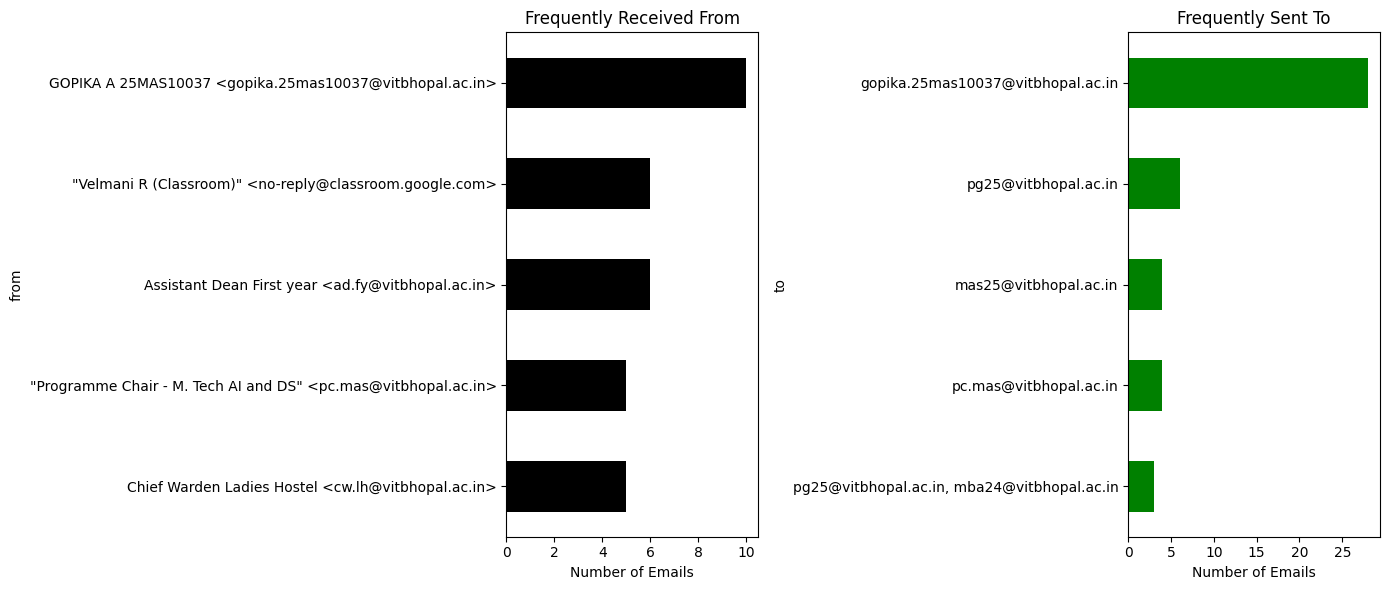

In [ ]:
#4. Whom do I communicate with most frequently?
import pandas as pd
import matplotlib.pyplot as plt
# Load CSV
df = pd.read_csv("gmail.csv")  # Change to your actual CSV path


# Remove cc and bcc columns if they exist
df = df.drop(columns=[col for col in ['cc', 'bcc'] if col in df.columns])

# Get top 5 'from' and 'to' emails
top_from = df['from'].value_counts().head(5)
top_to = df['to'].value_counts().head(5)

# Print them
print("Top 5 most frequent senders (from):")
print(top_from)
print("\nTop 5 most frequent recipients (to):")
print(top_to)

# Plot top 5 for both
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Received (from)
top_from.plot(kind='barh', ax=axes[0], color='black')
axes[0].invert_yaxis()
axes[0].set_title("Frequently Received From")
axes[0].set_xlabel("Number of Emails")

# Sent (to)
top_to.plot(kind='barh', ax=axes[1], color='green')
axes[1].invert_yaxis()
axes[1].set_title("Frequently Sent To")
axes[1].set_xlabel("Number of Emails")

plt.tight_layout()
plt.show()

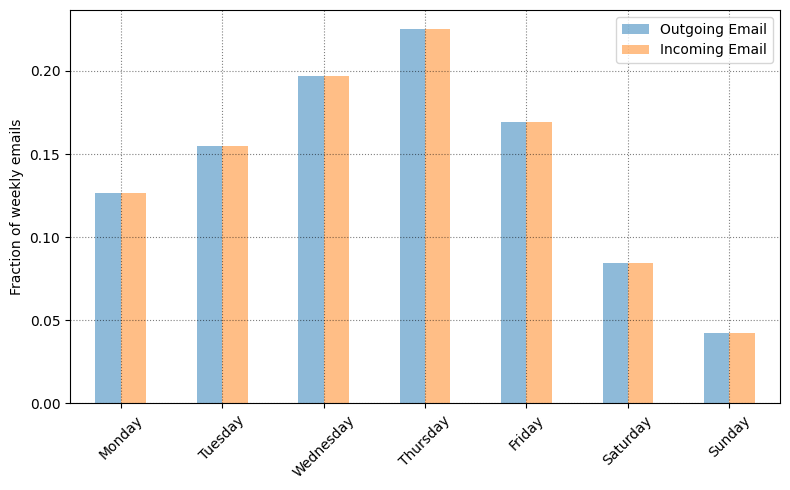

In [ ]:
#5. What are the most emailing days?
# Create dayofweek column from 'date' datetime column

import pandas as pd
import matplotlib.pyplot as plt

# Example: load CSVs
sent = pd.read_csv("gmail.csv")        # must contain a 'date' column
received = pd.read_csv("gmail.csv")  # must contain a 'date' column

# Ensure 'date' column is datetime
sent['date'] = pd.to_datetime(sent['date'])
received['date'] = pd.to_datetime(received['date'])

# Extract day of week (0=Monday, 6=Sunday)
sent['dayofweek'] = sent['date'].dt.day_name()
received['dayofweek'] = received['date'].dt.day_name()

# Group and calculate fraction
sdw = sent.groupby('dayofweek').size() / len(sent)
rdw = received.groupby('dayofweek').size() / len(received)

# Combine into one DataFrame
df_tmp = pd.DataFrame({'Outgoing Email': sdw, 'Incoming Email': rdw})

# Ensure days are in correct order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_tmp = df_tmp.reindex(days_order)

# Plot
df_tmp.plot(kind='bar', rot=45, figsize=(8,5), alpha=0.5)
plt.xlabel('')
plt.ylabel('Fraction of weekly emails')
plt.grid(ls=':', color='k', alpha=0.5)
plt.tight_layout()
plt.show()


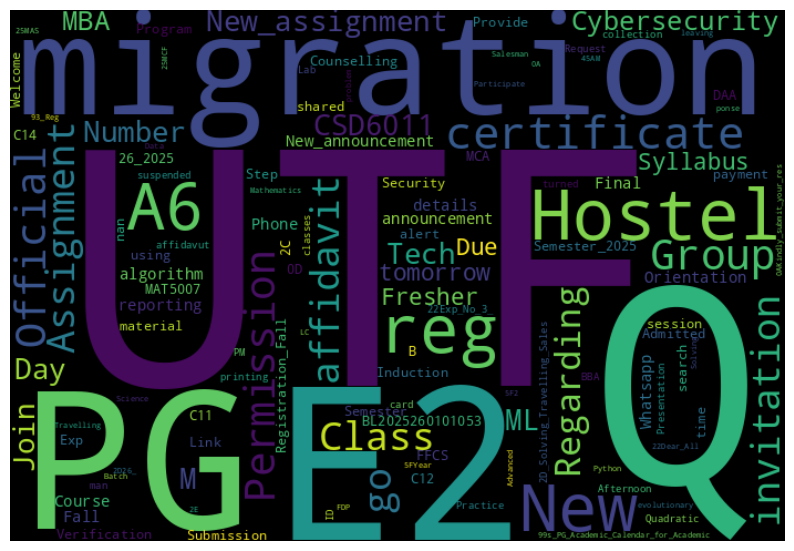

In [ ]:
#6.What is the most frequently used word in email?
from wordcloud import WordCloud
df_no_arxiv = dfs[dfs['from'] != 'no-reply@arXiv.org']
text = ' '.join(map(str, sent['subject'].values))

stopwords = ['Re', 'Fwd', '3A_']
wrd = WordCloud(width=700, height=480, margin=0, collocations=False)
for sw in stopwords:
   wrd.stopwords.add(sw)
wordcloud = wrd.generate(text)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)
